<a href="https://colab.research.google.com/github/Mirsha-RG/tallerprograma2/blob/projects/analisis_mercado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import pandas as pd
from scipy.stats import shapiro
import numpy as np
import seaborn as sns

url = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/MarketPower.csv"

df = pd.read_csv(url)
df

,Unnamed: 0,theta,beta,cm,sector
0,0,125.121419,31.5,9.799712,Software
1,1,125.645324,30.5,10.616998,Software
2,2,126.766324,17.5,9.426922,Software
3,3,127.141536,22.5,9.698818,Software
4,4,127.472341,28.5,9.042124,Software
...,...,...,...,...,...
122,0,1237.516764,24.4,4.306088,Financial
123,1,1236.938396,11.4,5.101223,Financial
124,2,1235.802773,12.4,4.073056,Financial
125,3,1237.271186,23.4,3.709515,Financial


In [79]:
#cantidad optima

df['q'] = (df['theta'] - df['cm'])/(2*df['beta']) # (theta - cm)  / ( 2 * beta)

In [80]:
df['Q'] = df.groupby(by=['sector'])['q'].transform("sum")
# Selecciona la columna 'q' Calcula la suma de los valores 'q' para cada grupo de sector

In [81]:
# porcentaje de participación

df['share'] = (df['q']/df['Q'])*100 # cantidad optima / el total del sector

In [82]:
shapiro(df['cm']).pvalue
# p-value
# H0: X sim N (los datos siguen una distribucion normal)
# Ha: X not sim N ((los datos NO siguen una distribucion normal))

np.float64(0.0002559126998811705)

In [83]:
print('mean: ', df['cm'].mean())
print('std: ', df['cm'].std())
print('Q50: ', df['cm'].quantile(0.5))
print('IQR: ', df['cm'].quantile(0.75))

mean:  6.9511329568324065
std:  1.8474482395966891
Q50:  6.838649584760122
IQR:  8.091295608474606


In [84]:
def descriptive(SERIE):
  if shapiro(SERIE).pvalue < 0.05:
    print('p50 - IQR')
    return SERIE.quantile(0.5), SERIE.quantile(0.75) - SERIE.quantile(0.25)
  else:
    print(' Mean - Std')
    return SERIE.mean(), SERIE.std()

In [85]:
for x in df['sector'].unique(): #valores unicos sin repetidos
  for n in ['cm', 'q']:
    print(x, n)
    print(descriptive(df[df['sector'] == x][n]))

Software cm
 Mean - Std
(np.float64(10.030047365822861), 1.1849260557929286)
Software q
p50 - IQR
(np.float64(2.7018747487014245), np.float64(3.2695156410170734))
Diapers cm
 Mean - Std
(np.float64(4.322634576267456), 0.1604878254223138)
Diapers q
 Mean - Std
(np.float64(302.5729722119885), 208.50462777670035)
Agriculture cm
p50 - IQR
(np.float64(6.5572289621841815), np.float64(2.2905057165746223))
Agriculture q
p50 - IQR
(np.float64(22.222841232788717), np.float64(19.447179552746398))
Financial cm
 Mean - Std
(np.float64(4.640863552259011), 0.9220248782705273)
Financial q
 Mean - Std
(np.float64(35.12045891583861), 15.517301156115423)


/tmp/ipython-input-84-516694490.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  if shapiro(SERIE).pvalue < 0.05:


In [86]:
def des_shapiro(SERIE):
  if shapiro(SERIE).pvalue < 0.05:
    return 'median ' + str( round(SERIE.quantile(0.5), 3))  + ' - ' + ' IQR ' + str(round(SERIE.quantile(0.75) - SERIE.quantile(0.25),3))
  else:
    return 'mean ' + str(round(SERIE.mean(),2))  + ' - ' + 'SD ' + str(round(SERIE.std(),2))


In [87]:
df.groupby(by=['sector'])['cm'].agg([des_shapiro])


/tmp/ipython-input-86-940567053.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  if shapiro(SERIE).pvalue < 0.05:


,des_shapiro
sector,
Agriculture,median 6.557 - IQR 2.291
Diapers,mean 4.32 - SD 0.16
Financial,mean 4.64 - SD 0.92
Software,mean 10.03 - SD 1.18


In [88]:
# coeficiente de variación

def scale(SERIE):
  return(SERIE - SERIE.mean()) / (SERIE.std())


In [89]:
df.groupby(by=['sector'])['q'].transform(scale)

,q
0,-0.635910
1,-0.626759
2,-0.383612
3,-0.506726
4,-0.594930
...,...
122,-0.634759
123,1.218478
124,0.937409
125,-0.564680


<Axes: xlabel='sector', ylabel='cm'>

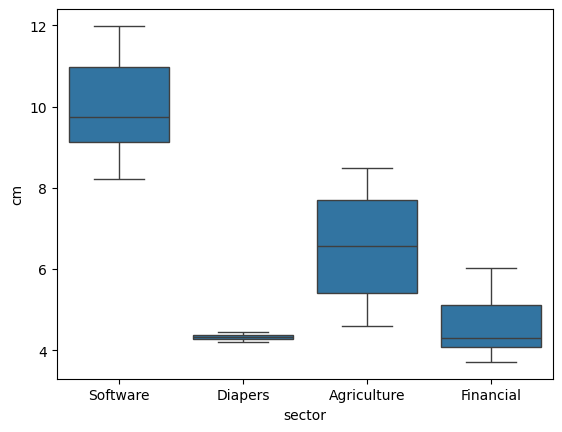

In [90]:
sns.boxplot(data = df, x = 'sector', y = 'cm')

<Axes: xlabel='sector', ylabel='q'>

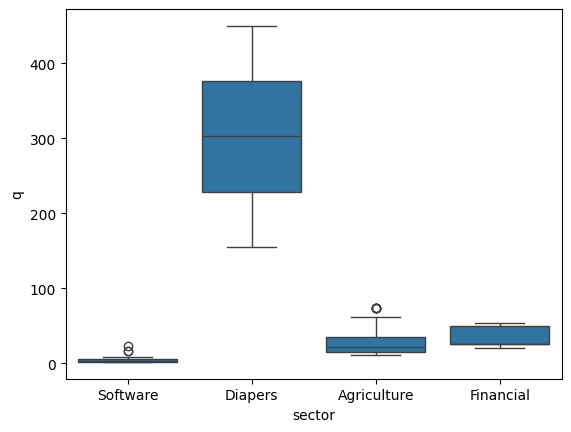

In [91]:
sns.boxplot(data = df, x = 'sector', y = 'q')

In [92]:
info_sector = {}
for sector in df['sector'].unique():
  info_sector[sector] = [df[df['sector']==sector]['q'].mean(),
                         df[df['sector']==sector]['q'].std()]

In [93]:
df['q-stand'] = 0

In [94]:
for index in df.index:
  sector = df.loc[index, 'sector']
  media = info_sector[sector][0]
  sd = info_sector[sector][1]
  df.loc[index, 'q-std'] = (df.loc[index, 'q'] - media) / sd
